### Mining CF metagenomes

In [18]:
### load packages
import math
import glob

import matplotlib.pyplot as plt
import numpy as np
import polars as pl
import seaborn as sns

In [25]:
### Identify CF genomovar representative IDs
# read sequence ids
cf_seqs = set(
    pl.read_csv('../uhvdb_cf_supplement/combined_hq_cf_viruses.seq-hasher.tsv.gz', separator='\t', has_header=False, new_columns=['seq_name', 'hash'])
        ['seq_name']
)

print(len(cf_seqs), 'CF sequences identified.')

332279 CF sequences identified.


In [60]:
### Load r2025_10 genomovar reps
r2025_10_seqs = pl.read_csv(
    '../uhvdb_final_files/r2025_10/uhvdb_clustering_thru_votus.tsv', separator='\t'
)
print(r2025_10_seqs.shape[0], 'r2025_10 sequences loaded.')

# identify number of reps that are in cf genomovars
genomovars_containing_allcf_seqs = set(
    r2025_10_seqs
        .filter(
            pl.col('seq_name').is_in(cf_seqs)
        )
        ['genomovar_rep']
)

genomovars_containing_metagcf_seqs = set(
    r2025_10_seqs
        .filter(
            (pl.col('seq_name').is_in(cf_seqs)) &
            (pl.col('seq_name').str.contains('_cf_k'))
        )
        ['genomovar_rep']
)

# identify number of reps that are in cf genomovars
species_containing_allcf_seqs = set(
    r2025_10_seqs
        .filter(
            pl.col('seq_name').is_in(cf_seqs)
        )
        ['votu_rep']
)

species_containing_metagcf_seqs = set(
    r2025_10_seqs
        .filter(
            (pl.col('seq_name').is_in(cf_seqs)) &
            (pl.col('seq_name').str.contains('_cf_k'))
        )
        ['votu_rep']
)

print(len(genomovars_containing_allcf_seqs), 'genomovars contain CF sequences.')
print(len(species_containing_allcf_seqs), 'species contain CF sequences.')
print(len(genomovars_containing_metagcf_seqs), 'genomovars contain metagenome-derived CF sequences.')
print(len(species_containing_metagcf_seqs), 'species contain metagenome-derived CF sequences.')

1107405 r2025_10 sequences loaded.
65611 genomovars contain CF sequences.
20781 species contain CF sequences.
3409 genomovars contain metagenome-derived CF sequences.
2455 species contain metagenome-derived CF sequences.


### Taxonomy of CF metagenome viruses

In [34]:
### Load proteinsmilarity
df = (
    pl.read_parquet('../figure_4/uhvdb_r2025_10_v_VMR_MSL40.v2.20251013.parquet')
        .filter(pl.col('column_1').is_in(species_containing_allcf_seqs))
)

print("Number of CF-virus containing species with a hit to ICTV:",
    df.unique(pl.col('column_1')).height
)

Number of CF-virus containing species with a hit to ICTV: 20777


In [39]:
### Count number of queries with family, subfamily, genus, subgenus, species level hits
print("Number of CF1-virus containing species with family hit to ICTV:",
    df.filter(pl.col('column_3') >= 5.5).unique('column_1').height
)

print("Number of CF1-virus containing species with subfamily hit to ICTV:",
    df.filter(pl.col('column_3') >= 32).unique('column_1').height
)

print("Number of CF1-virus containing species with genus hit to ICTV:",
    df.filter(pl.col('column_3') >= 65).unique('column_1').height
)

print("Number of CF1-virus containing species with subgenus hit to ICTV:",
    df.filter(pl.col('column_3') >= 80).unique('column_1').height
)

print("Number of CF1-virus containing species with species hit to ICTV:",
    df.filter(pl.col('column_3') >= 95).unique('column_1').height
)

Number of CF1-virus containing species with family hit to ICTV: 18977
Number of CF1-virus containing species with subfamily hit to ICTV: 7094
Number of CF1-virus containing species with genus hit to ICTV: 1966
Number of CF1-virus containing species with subgenus hit to ICTV: 402
Number of CF1-virus containing species with species hit to ICTV: 100


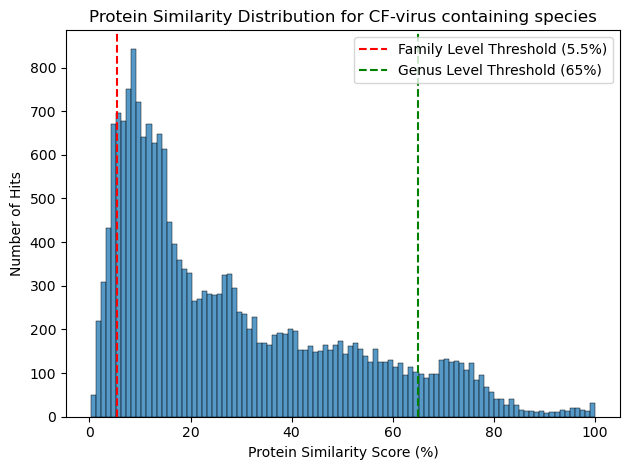

In [37]:
# create histogram of protein similarity scores
sns.histplot(data=df.group_by('column_1').agg([pl.col('column_3').max().alias('max_similarity')]), x='max_similarity', bins=100, kde=False)
plt.xlabel('Protein Similarity Score (%)')
plt.ylabel('Number of Hits')
plt.title('Protein Similarity Distribution for CF-virus containing species')
plt.axvline(x=5.5, color='red', linestyle='--', label='Family Level Threshold (5.5%)')
plt.axvline(x=65, color='green', linestyle='--', label='Genus Level Threshold (65%)')
plt.legend()
plt.tight_layout()
plt.show()

In [38]:
df_cf = df.filter(pl.col('column_1').is_in(species_containing_metagcf_seqs))
print("Number of CF-virus containing species with a hit to ICTV:",
    df_cf.unique(pl.col('column_1')).height
)

Number of CF-virus containing species with a hit to ICTV: 2452


In [40]:
### Count number of queries with family, subfamily, genus, subgenus, species level hits
print("Number of CF2-virus containing species with family hit to ICTV:",
    df_cf.filter(pl.col('column_3') >= 5.5).unique('column_1').height
)

print("Number of CF2-virus containing species with subfamily hit to ICTV:",
    df_cf.filter(pl.col('column_3') >= 32).unique('column_1').height
)

print("Number of CF2-virus containing species with genus hit to ICTV:",
    df_cf.filter(pl.col('column_3') >= 65).unique('column_1').height
)

print("Number of CF2-virus containing species with subgenus hit to ICTV:",
    df_cf.filter(pl.col('column_3') >= 80).unique('column_1').height
)

print("Number of CF2-virus containing species with species hit to ICTV:",
    df_cf.filter(pl.col('column_3') >= 95).unique('column_1').height
)

Number of CF2-virus containing species with family hit to ICTV: 1921
Number of CF2-virus containing species with subfamily hit to ICTV: 395
Number of CF2-virus containing species with genus hit to ICTV: 79
Number of CF2-virus containing species with subgenus hit to ICTV: 34
Number of CF2-virus containing species with species hit to ICTV: 10


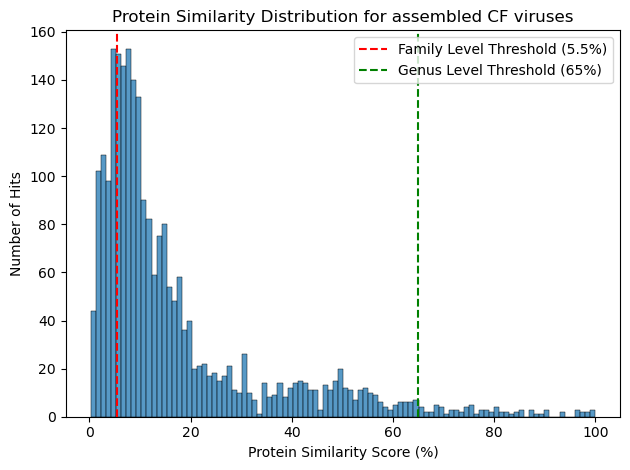

In [59]:
# create histogram of protein similarity scores
sns.histplot(data=df_cf.group_by('column_1').agg([pl.col('column_3').max().alias('max_similarity')]), x='max_similarity', bins=100, kde=False)
plt.xlabel('Protein Similarity Score (%)')
plt.ylabel('Number of Hits')
plt.title('Protein Similarity Distribution for assembled CF viruses')
plt.axvline(x=5.5, color='red', linestyle='--', label='Family Level Threshold (5.5%)')
plt.axvline(x=65, color='green', linestyle='--', label='Genus Level Threshold (65%)')
plt.legend()
plt.tight_layout()
plt.show()

### Host characteristics of CF viruses

In [42]:
### load phist + crispr host information
uhvdb_phisttaxa = pl.read_csv('../figure_4/uhvdb_r2025_10_species_phist_host_predictions.tsv', separator='\t').filter(pl.col('votu_rep').is_in(species_containing_allcf_seqs))
uhvdb_crisprtaxa = pl.read_csv('../figure_4/uhvdb_r2025_10_species_spacer_host_predictions.tsv', separator='\t').filter(pl.col('votu_rep').is_in(species_containing_allcf_seqs))

In [43]:
### prioritize crispr when available
uhvdb_combinedtaxa = (
    uhvdb_phisttaxa[['votu_rep', 'consensus_species', 'species_max_count', 'consensus_genus', 'genus_max_count', 'consensus_family', 'family_max_count']]
        .join(
            uhvdb_crisprtaxa[['votu_rep', 'consensus_species', 'species_max_count', 'consensus_genus', 'genus_max_count', 'consensus_family', 'family_max_count']],
            on='votu_rep',
            how='full',
            suffix='_crispr'
        )
        .with_columns([
            pl.col('species_max_count').fill_null(0).alias('species_max_count'),
            pl.col('genus_max_count').fill_null(0).alias('genus_max_count'),
            pl.col('family_max_count').fill_null(0).alias('family_max_count'),
            pl.col('species_max_count_crispr').fill_null(0).alias('species_max_count_crispr'),
            pl.col('genus_max_count_crispr').fill_null(0).alias('genus_max_count_crispr'),
            pl.col('family_max_count_crispr').fill_null(0).alias('family_max_count_crispr'),
        ])
        .with_columns([
            pl.when((pl.col('consensus_species').is_not_null()) & (pl.col('species_max_count') > pl.col('species_max_count_crispr'))).then(pl.col('consensus_species'))
                .when(pl.col('consensus_species_crispr').is_not_null()).then(pl.col('consensus_species_crispr'))
                .otherwise(pl.lit(None)).alias('species'),
            pl.when((pl.col('consensus_genus').is_not_null()) & (pl.col('genus_max_count') > pl.col('genus_max_count_crispr'))).then(pl.col('consensus_genus'))
                .when(pl.col('consensus_genus_crispr').is_not_null()).then(pl.col('consensus_genus_crispr'))
                .otherwise(pl.lit(None)).alias('genus'),
            pl.when((pl.col('consensus_family').is_not_null()) & (pl.col('family_max_count') > pl.col('family_max_count_crispr'))).then(pl.col('consensus_family'))
                .when(pl.col('consensus_family_crispr').is_not_null()).then(pl.col('consensus_family_crispr'))
                .otherwise(pl.lit(None)).alias('family'),
        ])
)

In [44]:
### Count number of host assignments at each rank
print(uhvdb_combinedtaxa.filter(pl.col('species').is_not_null()).height/uhvdb_combinedtaxa.height)
print(uhvdb_combinedtaxa.filter(pl.col('genus').is_not_null()).height/uhvdb_combinedtaxa.height)
print(uhvdb_combinedtaxa.filter(pl.col('family').is_not_null()).height/uhvdb_combinedtaxa.height)

0.6887872954764196
0.8299326275264678
0.8957170356111646


In [45]:
print(uhvdb_combinedtaxa.filter((pl.col('species').is_not_null()) & (pl.col('votu_rep').is_in(species_containing_metagcf_seqs))).height/uhvdb_combinedtaxa.filter(pl.col('votu_rep').is_in(species_containing_metagcf_seqs)).height)
print(uhvdb_combinedtaxa.filter((pl.col('genus').is_not_null()) & (pl.col('votu_rep').is_in(species_containing_metagcf_seqs))).height/uhvdb_combinedtaxa.filter(pl.col('votu_rep').is_in(species_containing_metagcf_seqs)).height)
print(uhvdb_combinedtaxa.filter((pl.col('family').is_not_null()) & (pl.col('votu_rep').is_in(species_containing_metagcf_seqs))).height/uhvdb_combinedtaxa.filter(pl.col('votu_rep').is_in(species_containing_metagcf_seqs)).height)

0.4963325183374083
0.9470252648736757
0.9718826405867971


In [64]:
### Identify top host taxa for each body site
uhvdb_top_taxa_lst = []
for rank in ['genus']:
    subset = uhvdb_combinedtaxa.filter(pl.col('votu_rep').is_in(species_containing_allcf_seqs))

    # identify top 10 taxa at this rank
    taxa_counts = (
        subset
            .group_by([rank])
            .len()
            .sort('len', descending=True)
    )

    top10taxa = taxa_counts.head(10)[rank].to_list()

    # group less common taxa as 'Other' and compute counts
    grouped_taxa = (
        subset
            .filter(pl.col(rank).is_not_null())
            .with_columns([
                pl.when(pl.col(rank).is_in(top10taxa))
                    .then(pl.col(rank))
                    .otherwise(pl.lit('Other'))
                    .alias('taxa_grouped')
            ])
            .group_by(['taxa_grouped'])
            .len()
            .sort('len', descending=True)
    )

    uhvdb_top_taxa_lst.append(grouped_taxa)

uhvdb_host_annotations = pl.concat(uhvdb_top_taxa_lst)

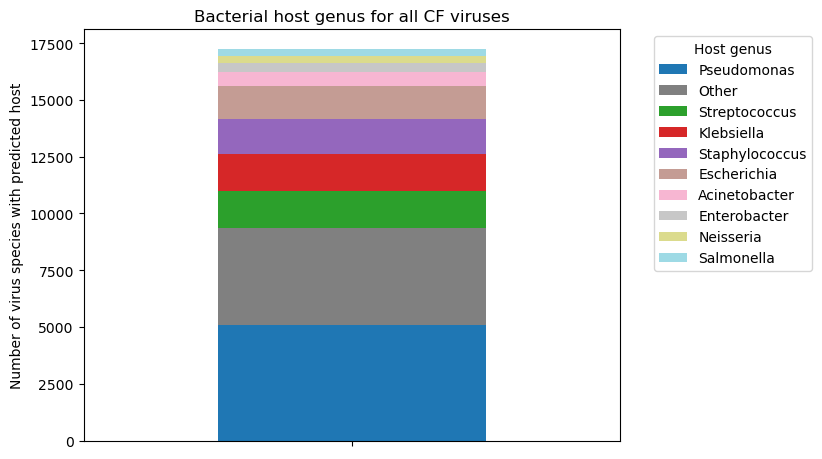

In [66]:
# create a stacked bar chart showing host taxa distribution at genus & phylum
# Set up the matplotlib figure
stacked_data = uhvdb_host_annotations.with_columns([pl.lit('CF viruses').alias('body_site')]).pivot(
    # index='body_site',
    on='taxa_grouped',
    values='len'
).fill_null(0)

stacked_data.to_pandas().plot(kind='bar', stacked=True, colormap='tab20', ax=plt.gca())
plt.title('Bacterial host genus for all CF viruses')
plt.ylabel('Number of virus species with predicted host')
plt.tight_layout()
# make x axis lablels horizontal
plt.xticks(rotation=0)
# make 'Other' category gray
ax = plt.gca()
handles, labels = ax.get_legend_handles_labels()
for i, label in enumerate(labels):
    if label == 'Other':
        # For stacked bars, the handle is a BarContainer with patches
        for patch in handles[i]:
            patch.set_facecolor('gray')
plt.legend(handles, labels, title='Host genus', bbox_to_anchor=(1.05, 1), loc='upper left')
# change x-tick labels
plt.xticks(ticks=range(len(stacked_data)), labels='')
plt.show()

In [46]:
### Identify top host taxa for each body site
uhvdb_top_taxa_lst = []
for rank in ['genus']:
    subset = uhvdb_combinedtaxa.filter(pl.col('votu_rep').is_in(species_containing_metagcf_seqs))

    # identify top 10 taxa at this rank
    taxa_counts = (
        subset
            .group_by([rank])
            .len()
            .sort('len', descending=True)
    )

    top10taxa = taxa_counts.head(10)[rank].to_list()

    # group less common taxa as 'Other' and compute counts
    grouped_taxa = (
        subset
            .filter(pl.col(rank).is_not_null())
            .with_columns([
                pl.when(pl.col(rank).is_in(top10taxa))
                    .then(pl.col(rank))
                    .otherwise(pl.lit('Other'))
                    .alias('taxa_grouped')
            ])
            .group_by(['taxa_grouped'])
            .len()
            .sort('len', descending=True)
    )

    uhvdb_top_taxa_lst.append(grouped_taxa)

uhvdb_host_annotations = pl.concat(uhvdb_top_taxa_lst)

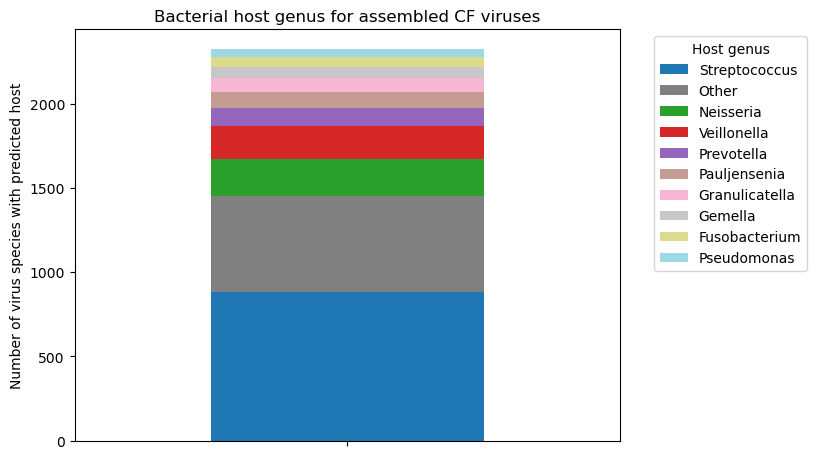

In [58]:
# create a stacked bar chart showing host taxa distribution at genus & phylum
# Set up the matplotlib figure
stacked_data = uhvdb_host_annotations.with_columns([pl.lit('CF viruses').alias('body_site')]).pivot(
    # index='body_site',
    on='taxa_grouped',
    values='len'
).fill_null(0)

stacked_data.to_pandas().plot(kind='bar', stacked=True, colormap='tab20', ax=plt.gca())
plt.title('Bacterial host genus for assembled CF viruses')
plt.ylabel('Number of virus species with predicted host')
plt.tight_layout()
# make x axis lablels horizontal
plt.xticks(rotation=0)
# make 'Other' category gray
ax = plt.gca()
handles, labels = ax.get_legend_handles_labels()
for i, label in enumerate(labels):
    if label == 'Other':
        # For stacked bars, the handle is a BarContainer with patches
        for patch in handles[i]:
            patch.set_facecolor('gray')
plt.legend(handles, labels, title='Host genus', bbox_to_anchor=(1.05, 1), loc='upper left')
# change x-tick labels
plt.xticks(ticks=range(len(stacked_data)), labels='')
plt.show()

In [63]:
(
    uhvdb_combinedtaxa
        .filter(
            (pl.col('votu_rep').is_in(species_containing_allcf_seqs)) &
            (
                (pl.col('genus').str.contains('Pseudomonas')) |
                (pl.col('genus').str.contains('Burkholderia')) |
                (pl.col('genus').str.contains('Staphylococcus')) |
                (pl.col('genus').str.contains('Stenotrophomonas')) |
                (pl.col('genus').str.contains('Achromobacter')) |
                (pl.col('genus').str.contains('Haemophilus'))
            )
        )
        .group_by('genus')
        .len()
)

genus,len
str,u32
"""Haemophilus_D""",29
"""Pseudomonas_E""",48
"""Pseudomonas_B""",2
"""Staphylococcus""",1545
"""Burkholderia""",46
…,…
"""Achromobacter""",87
"""Pseudomonas""",5106
"""Haemophilus_A""",10


In [52]:
(
    uhvdb_combinedtaxa
        .filter(
            (pl.col('votu_rep').is_in(species_containing_metagcf_seqs)) &
            (
                (pl.col('genus').str.contains('Pseudomonas')) |
                (pl.col('genus').str.contains('Burkholderia')) |
                (pl.col('genus').str.contains('Staphylococcus')) |
                (pl.col('genus').str.contains('Stenotrophomonas')) |
                (pl.col('genus').str.contains('Achromobacter')) |
                (pl.col('genus').str.contains('Haemophilus'))
            )
        )
        .group_by('genus')
        .len()
)

genus,len
str,u32
"""Achromobacter""",1
"""Pseudomonas_E""",5
"""Haemophilus_A""",8
"""Pseudomonas""",49
"""Staphylococcus""",7
"""Stenotrophomonas""",4
"""Haemophilus_D""",16
"""Haemophilus""",14


### Lifestyles for CF containing viruses

In [69]:
### load UHGV integration data

# # Download genomad stats file
# !wget https://portal.nersc.gov/cfs/m342/UHGV/mysql/tsv/genomad_viral_stats.tsv

uhgv_proviruses = set(
    pl.read_csv('../figure_4/genomad_viral_stats.tsv', separator='\t', columns=['contig_id', 'provirus'])
    .filter(pl.col('provirus') == "Yes")
    ['contig_id']
)

### get OPD provirus info
# 1. download Excel sheet with metadata: https://static-content.springer.com/esm/art%3A10.1038%2Fs41522-025-00773-z/MediaObjects/41522_2025_773_MOESM2_ESM.xlsx
# 2. Filter Table3-OPD quality to identify 'replace_id' with 'checkv_provirus' == "Yes"
# 3. Save as TSV: opd_checkv_proviruses.tsv
opd_proviruses = set(
    pl.read_csv('../figure_4/opd_checkv_provirus.tsv', separator='\t', columns=['replace_id'])
    ['replace_id']
)

### Get CNGVC integration information
# CNGVC did not perform host trimming, so just used UHVDB provirus info

#### get CGVR provirus info
# 1. CGVR metadata downloaded from: https://static-content.springer.com/esm/art%3A10.1186%2Fs40168-025-02185-9/MediaObjects/40168_2025_2185_MOESM1_ESM.xlsx
# 2. Filter Table S1 to identify 'Viral_bin_id' with 'provirus' == "Yes"
# 3. Save as TSV: cgvr_checkv_proviruses.tsv
cgvr_proviruses = set(
    pl.read_csv('../figure_4/cgvr_checkv_proviruses.tsv', separator='\t', columns=['Viral_bin_id'])
    ['Viral_bin_id']
)

### get IMGVR integration info
# 1. Download IMGVR metadata from: https://genome.jgi.doe.gov/portal/pages/dynamicOrganismDownload.jsf?organism=IMG_VR
imgvr_proviruses = set(
    pl.read_csv('../figure_1/IMGVR_all_Sequence_information.tsv', separator='\t', columns=['UVIG', 'Topology'])
        .filter(pl.col('Topology') == 'Provirus')
        ['UVIG']
)

### get mMGE provirus info
# 1. Download mMGE metadata from: https://mai.fudan.edu.cn/mgedb/client/file/all_mge_inf.zip
mmge_proviruses = set(
    pl.read_csv('../figure_1/all_mge_inf.csv')
        .filter(pl.col('prophage') == True)
        ['MGEs_id']
)

In [70]:
### load bacphlip results for UHVDB r2025_09
bacphlip_lst = []
for file in glob.glob('../figure_4/uhvdb*genomovar_chunks/*.bacphlip'):
    df = (
        pl.read_csv(file, separator='\t', null_values=['NA'], new_columns=['contig_id', 'virulent', 'temperate'])
    )
    bacphlip_lst.append(df)

Number of seqs with BACPHLIP results: 20780


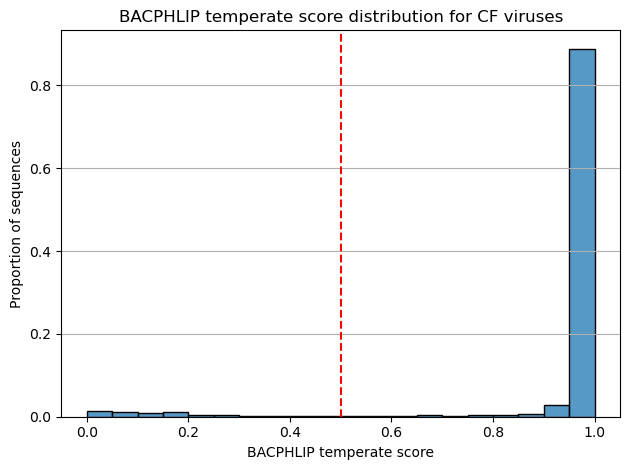

In [73]:
### plot histogram (using proportion instead of count) of temperate scores by completeness status
# set integrated sequences to temperate score of 1.0
bacphlip_df = (
    pl.concat(bacphlip_lst)
        .filter(pl.col('contig_id').is_in(species_containing_allcf_seqs))
        .with_columns([
            pl.when(pl.col('contig_id').str.contains('provirus'))
                .then(pl.lit(1.0))
                .when(pl.col('contig_id').is_in(uhgv_proviruses))
                .then(pl.lit(1.0))
                .when(pl.col('contig_id').is_in(opd_proviruses))
                .then(pl.lit(1.0))
                .when(pl.col('contig_id').is_in(cgvr_proviruses))
                .then(pl.lit(1.0))
                .when(pl.col('contig_id').is_in(imgvr_proviruses))
                .then(pl.lit(1.0))
                .when(pl.col('contig_id').is_in(mmge_proviruses))
                .then(pl.lit(1.0))
                .otherwise(pl.col('temperate')).alias('temperate'),
        ])
)

print("Number of seqs with BACPHLIP results:", bacphlip_df.height)

sns.histplot(data=bacphlip_df.filter(pl.col('contig_id').is_in(species_containing_allcf_seqs)), x='temperate', stat='proportion', bins=20, multiple='stack', kde=False)
plt.xlabel('BACPHLIP temperate score')
plt.ylabel('Proportion of sequences')
plt.title('BACPHLIP temperate score distribution for CF viruses')
plt.grid(axis='y')
plt.tight_layout()
# add vertical line at 0.5
plt.axvline(x=0.5, color='red', linestyle='--')
plt.show()

### Functional annotations for CF viruses

In [74]:
### Identify ARGs using alignment to CARD
card_dir = "../figure_4/function/tmp/2026_01_08/annotate/function/card/diamond/*.fna/*.fna.card.tsv.gz"
card_lst = []
for file in glob.glob(card_dir):
    try:
        df = pl.read_csv(file, separator='\t', has_header=False, columns=[0, 1])
        card_lst.append(df)
    except pl.exceptions.NoDataError:
        continue

card_df = (
    pl.concat(card_lst)
    .with_columns([pl.col('column_1').str.replace(r"_[^_]*$", "")])
    .with_columns([pl.col('column_1').str.replace('uhvdb_votu_reps.fna_', '')])
    .filter(pl.col('column_1').is_in(species_containing_allcf_seqs))
    .group_by('column_1')
    .len()
)
print(f"Total genomes with CARD hits: {card_df.height}")

Total genomes with CARD hits: 47


In [76]:
### Identify VFs using alignment to VFDB
### VFDB
vfdb_dir = "../figure_4/function/tmp/2026_01_08/annotate/function/vfdb/diamond/*.fna/*.fna.vfdb.tsv.gz"
vfdb_lst = []
for file in glob.glob(vfdb_dir):
    try:
        df = pl.read_csv(file, separator='\t', has_header=False, columns=[0, 1])
        vfdb_lst.append(df)
    except pl.exceptions.NoDataError:
        continue

vfdb_df = (
    pl.concat(vfdb_lst)
    .with_columns([pl.col('column_1').str.replace(r"_[^_]*$", "")])
    .with_columns([pl.col('column_1').str.replace('uhvdb_votu_reps.fna_', '')])
    .filter(pl.col('column_1').is_in(species_containing_allcf_seqs))
    .group_by('column_1')
    .len()
)
print(f"Total genomes with VFDB hits: {vfdb_df.height}")

Total genomes with VFDB hits: 1230


In [77]:
### Count defense systems identified via defense finder
df_dir = "../figure_4/function/tmp/2026_01_08/annotate/function/defensefinder/run/*.fna/*systems.tsv.gz"
df_lst = []
for file in glob.glob(df_dir):
    try:
        df = pl.read_csv(file, separator='\t', ignore_errors=True, columns=['sys_id', 'type', 'activity', 'protein_in_syst'])
        df_lst.append(df)
    except pl.exceptions.NoDataError:
        continue

df_df = (
    pl.concat(df_lst)
        .filter(pl.col('activity') == 'Defense')
        .with_columns([pl.col('protein_in_syst').str.split(',').list[0].str.replace(r"_[^_]*$", "")])
        .with_columns([pl.col('protein_in_syst').str.replace('uhvdb_votu_reps.fna_', '')])
        .filter(pl.col('protein_in_syst').is_in(species_containing_allcf_seqs))
        .group_by('protein_in_syst')
        .len()
)
print(f"Total Defense Finder genomes: {df_df.height}")

Total Defense Finder genomes: 2769


In [78]:
### Count anti-defense systems identified via defense finder
antidf_df = (
    pl.concat(df_lst)
        .filter(pl.col('activity') == 'Antidefense')
        .with_columns([pl.col('protein_in_syst').str.split(',').list[0].str.replace(r"_[^_]*$", "")])
        .with_columns([pl.col('protein_in_syst').str.replace('uhvdb_votu_reps.fna_', '')])
        .filter(pl.col('protein_in_syst').is_in(species_containing_allcf_seqs))
        .group_by('protein_in_syst')
        .len()
)
print(f"Total Anti-Defense Finder genomes: {df_df.height}")

Total Anti-Defense Finder genomes: 2769


In [79]:
### Count anti-defense systems identified via dbAPIs
pharokka_dir = "../figure_4/function/tmp/2026_01_08/annotate/function/pharokka/pharokka/*.fna/*.tsv.gz"
pharokka_lst = []
for file in glob.glob(pharokka_dir):
    try:
        df = (
            pl.read_csv(file, separator='\t', ignore_errors=True, columns=['gene', 'contig', 'custom_hmm_id', 'annot'])
                .filter(
                    (pl.col('custom_hmm_id') != 'No_custom_HMM') |
                    (pl.col('annot') == 'major head protein') |
                    (pl.col('annot') == 'terminase large subunit') |
                    (pl.col('annot') == 'portal protein') |
                    (pl.col('annot').str.contains('integrase')) |
                    (pl.col('annot').str.contains('recombinase'))
                )
        )
        pharokka_lst.append(df)
    except pl.exceptions.NoDataError:
        continue

pharokka_df = (
    pl.concat(pharokka_lst)
    .with_columns([pl.col('contig').str.replace('uhvdb_votu_reps.fna_', '')])
    .filter(pl.col('contig').is_in(species_containing_allcf_seqs))
)
print(f"Total Pharokka genomes: {pharokka_df.unique('contig').height}")

Total Pharokka genomes: 18800


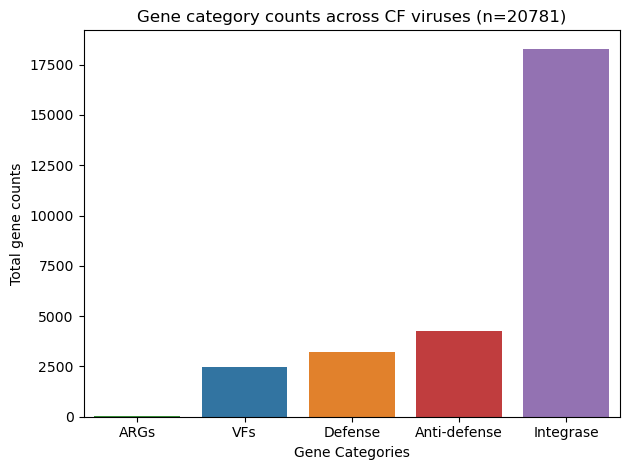

In [81]:
### CARD, VFDB, DefenseFinder, antidefensefinder, integrase
card_df_plot = card_df.rename({'column_1': 'genome', 'len': 'count'}).with_columns([pl.lit('ARGs').alias('target')])
vfdb_df_plot = vfdb_df.rename({'column_1': 'genome', 'len': 'count'}).with_columns([pl.lit('VFs').alias('target')])
df_df_plot = df_df.rename({'protein_in_syst': 'genome', 'len': 'count'}).with_columns([pl.lit('Defense').alias('target')])
antidf_df_plot = antidf_df.rename({'protein_in_syst': 'genome', 'len': 'count'}).with_columns([pl.lit('Anti-defense').alias('target')])
pharokka_df_plot = (
    pharokka_df
        .filter(
            (pl.col('annot').str.contains('integrase')) |
            (pl.col('annot').str.contains('recombinase'))
        )
        .group_by('contig')
        .len()
        .rename({'contig': 'genome', 'len': 'count'})
        .with_columns([pl.lit('Integrase').alias('target')])
)

### create a figure of the number of genes of interest per genome
plot_df = (
    pl.concat([card_df_plot, vfdb_df_plot, df_df_plot, antidf_df_plot, pharokka_df_plot])
        .group_by('target')
        .agg(pl.col('count').sum().alias('total_counts'))
)
sns.barplot(data=plot_df, x='target', y='total_counts', order=['ARGs', 'VFs', 'Defense', 'Anti-defense', 'Integrase'], hue='target')
plt.xlabel('Gene Categories')
plt.ylabel('Total gene counts')
plt.title('Gene category counts across CF viruses (n=20781)')
plt.tight_layout()
plt.show()